# Forecasting Macroeconomic Trends: The Nexus of Exchange Rates, Energy, and CP

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRFRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import yfinance as yf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from pmdarima.arima.utils import nsdiffs
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
import warnings 
warnings.filterwarnings('ignore', category=FutureWarning)
from xgboost import XGBRegressor

## 1. Data Collection

### 1.1 Inflation

In [2]:
# Inflation is pulled from bsp site.
# link: https://www.bsp.gov.ph/Statistics/Prices/tab34_inf_2018.aspx

inflation_df = pd.read_excel('Inflation_rates_dataset_2021-2026.xlsx')
inflation_df['month'] = pd.to_datetime(inflation_df['month']).dt.to_period('M').dt.to_timestamp()
inflation_df = inflation_df.set_index('month')

### 1.2 Sentiment Analysis

In [3]:
# Sentiment Analysis was scraped, cleaned, process in different .ipynb as it takes time to scrape headers
# Newsline headers source link: www.bworldonline.com/banking-finance/

sentiment_df = pd.read_csv('finBERT Sentiment-Inflation.csv')
sentiment_df['month'] = pd.to_datetime(sentiment_df['date']).dt.to_period('M').dt.to_timestamp()
sentiment_df = sentiment_df.drop(columns = ['date'], errors = 'ignore')

### 1.3 Oil Brent

In [4]:
oil_df = yf.download(tickers='BZ=F', start='2021-01-01', end = '2026-06-01', interval='1d')
oil_df = oil_df['Close'].resample('M').mean()
oil_df.columns = ['oil_brent']
oil_df = oil_df.reset_index()
oil_df['month'] = oil_df['Date']
oil_df = oil_df.drop(columns = 'Date', errors = 'ignore')
oil_df['month'] = pd.to_datetime(oil_df['month']).dt.to_period('M').dt.to_timestamp()

[*********************100%***********************]  1 of 1 completed


### 1.4 Merging dataframes

In [5]:
df = pd.merge(sentiment_df, oil_df, on='month', how='inner').drop(columns = 'inflation', errors='ignore').set_index('month')
df = df.join(inflation_df, how = 'left')

In [6]:
print(f'DataFrame Information:')
print(f'Length: {len(df)}')
print(f'NAs: {df.isna().sum()}')
print('Head:')
print(df.head())
print('Tail:')
print(df.tail())

DataFrame Information:
Length: 65
NAs: sentiment    0
oil_brent    0
inflation    2
dtype: int64
Head:
            sentiment  oil_brent  inflation
month                                      
2021-01-01  -0.096034  55.351579        3.7
2021-02-01   0.019575  62.227894        4.2
2021-03-01  -0.041243  65.702174        4.1
2021-04-01   0.023667  65.328572        4.1
2021-05-01  -0.017046  68.258500        4.1
Tail:
            sentiment   oil_brent  inflation
month                                       
2026-01-01  -0.028967   64.765499        2.0
2026-02-01  -0.000079   69.406843        2.4
2026-03-01   0.023276   99.599546        4.1
2026-04-01   0.013479  102.464286        NaN
2026-05-01   0.078773  104.092000        NaN


## 2 Exploratory Data Analysis

### 2.1 Correlation Analysis and Stationarity Check

In [7]:
print('Energy vs Inflation correlation through lags:')
print('')
for lag in [0, 1, 2, 3, 4]:
    lagged_corr = df['inflation'].corr(df['oil_brent'].rolling(window = 3).mean().shift(lag))
    print(f"Oil Brent (Lag {lag}) vs Inflation Corr: {lagged_corr:.4f}")

print('')
print('Sentiment Analysis vs Inflation Correlation through lags:')
print('')
for lag in [0, 1, 2, 3, 4]:
    lagged_corr = df['inflation'].dropna().corr(df['sentiment'].rolling(window = 3).mean().shift(lag))
    print(f"Sentiment (Lag {lag}) vs Inflation Corr: {lagged_corr:.4f}")
print('')

print('ADF Test for stationarity checking') 

def adf_test(series):
    result = adfuller(series)[1]

    if result > 0.05:
        print(f'ADF: {result}, differencing is needed')
    else:
        print(f'ADF: {result}, no differencing needed. Data is stationary')

def ndiffs(series):
    result = nsdiffs(series, m=12, test='ocsb')
    print(f'Suggested Seasonal Differencing: {result}')
adf_test(df['inflation'].dropna())
ndiffs(df['inflation'].dropna())

Energy vs Inflation correlation through lags:

Oil Brent (Lag 0) vs Inflation Corr: 0.6226
Oil Brent (Lag 1) vs Inflation Corr: 0.6493
Oil Brent (Lag 2) vs Inflation Corr: 0.6735
Oil Brent (Lag 3) vs Inflation Corr: 0.7006
Oil Brent (Lag 4) vs Inflation Corr: 0.7229

Sentiment Analysis vs Inflation Correlation through lags:

Sentiment (Lag 0) vs Inflation Corr: 0.4130
Sentiment (Lag 1) vs Inflation Corr: 0.4294
Sentiment (Lag 2) vs Inflation Corr: 0.4417
Sentiment (Lag 3) vs Inflation Corr: 0.4162
Sentiment (Lag 4) vs Inflation Corr: 0.3793

ADF Test for stationarity checking
ADF: 0.13346084422113258, differencing is needed
Suggested Seasonal Differencing: 0


### 2.2 ACF/PACF Plots

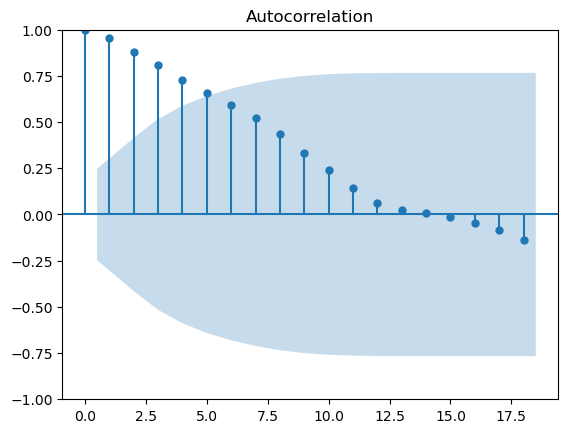

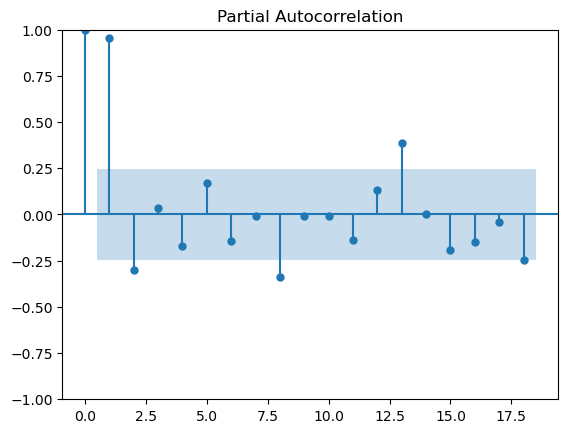

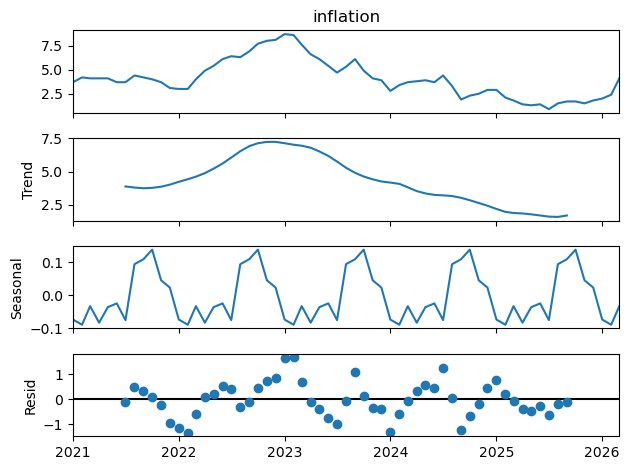

In [8]:
plot_acf(df['inflation'].dropna())
plot_pacf(df['inflation'].dropna())

decomp = seasonal_decompose(df['inflation'].dropna(), model = 'additive', period = 12)
decomp.plot()
plt.tight_layout()
plt.show()

# This shows that nsdiffs prove that no Seasonal Differencing needed
# Other tests like ACF and PACF and Seasonal Decomposition shows that there is a weak seasonality.
# Auto ARIMA will be used and make sure that Seasonal Differencing is not included

## 3. Feature Engineering

### 3.1 Feature Engineering

In [9]:
df['oil_brent'] = df['oil_brent'].rolling(window=3).mean().shift(2)
df['sentiment'] = df['sentiment'].rolling(window=3).mean().shift(2)
df = df[5:]
X_future = df[-2:].drop(columns = 'inflation', errors='ignore')

### 3.2 Train/Test Split

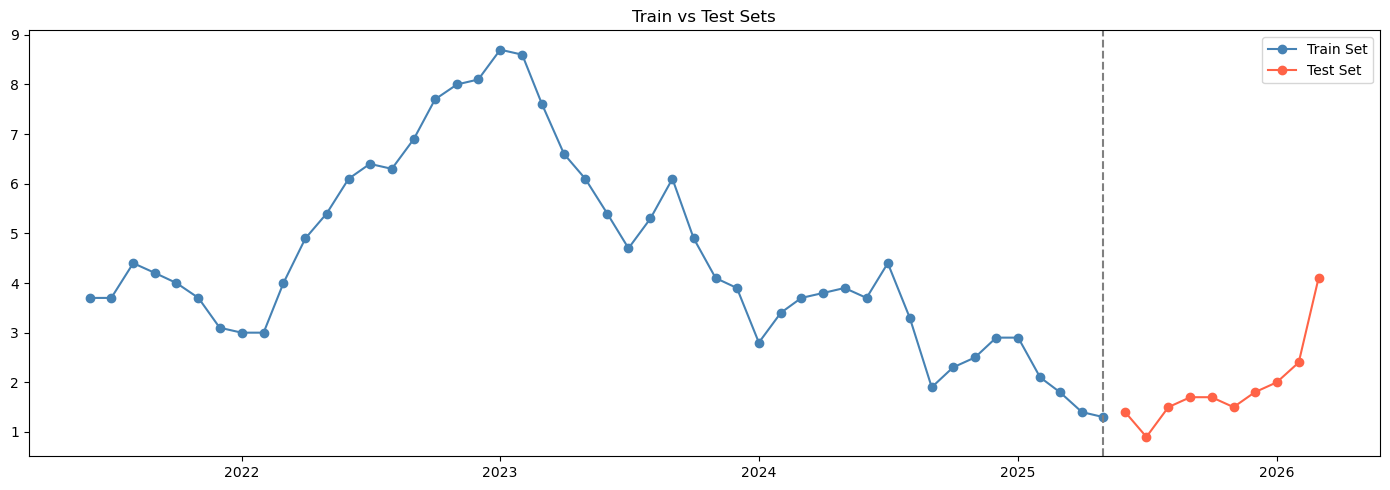

In [35]:
split = int(len(df)*0.8)
train = df.iloc[:split]
test = df.iloc[split:]

fig, ax = plt.subplots(figsize=(14,5))

ax.plot(train['inflation'], color = 'steelblue', label='Train Set', marker='o')
ax.plot(test['inflation'], color = 'tomato', label='Test Set',marker='o')

ax.axvline(train.index.max(), color='grey', linestyle='--')
ax.set_title('Train vs Test Sets')

plt.legend()
plt.tight_layout()
plt.show()

## 4. Modeling and Initial Evaluation

#### 4.1 SARIMA Modeling 

In [11]:
arima_model = auto_arima(train['inflation'].dropna(),
                         seasonal = True,    # Seasonality is weak but there's signal so we want to capture it
                         m=12,               # For monthly data
                         d=1,                # ADF test proved that differencing is needed 
                         D=0,                # nsdiff proved that seasonal differencing is not needed
                         max_p=3,
                         max_q=3,
                         max_P=2,
                         max_Q=2,
                         stepwise=False,     # For exhaustive search instead of stepwise
                         information_criterion='aic')

#### 4.2 Model Summary, Forecast, Evaluation and Plot

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                   48
Model:             SARIMAX(0, 1, 3)x(1, 0, [], 12)   Log Likelihood                 -29.406
Date:                             Mon, 08 Jun 2026   AIC                             70.812
Time:                                     18:14:16   BIC                             81.913
Sample:                                 06-01-2021   HQIC                            74.989
                                      - 05-01-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0896      0.143     -0.625      0.532      -0.371       0.191
ma.L1          0.4690      

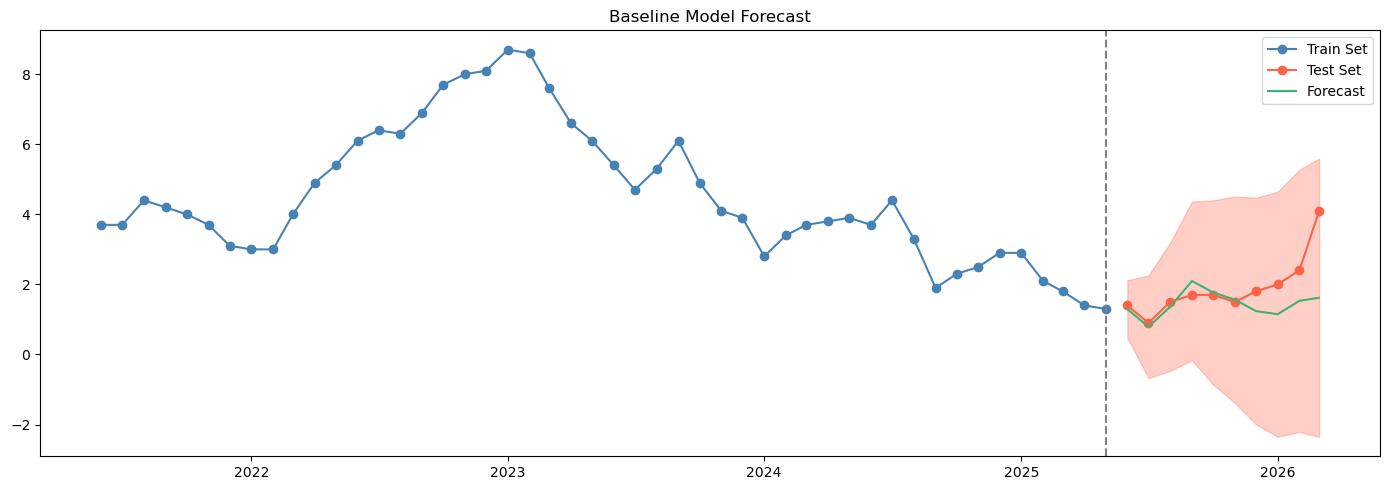

In [34]:
# SARIMA model summary
print(arima_model.summary())

# Forecasting 
forecast, conf_int = arima_model.predict(n_periods=len(test.dropna()), return_conf_int=True)

# SARIMA Forecast Evaluation
def err_metrics(y_true, y_pred):
    # 1. Mean Squared Error (MSE)
    mse = mean_squared_error(y_true, y_pred)
    
    # 2. Root Mean Squared Error (RMSE)
    # In newer versions of sklearn, you can use squared=False
    rmse = root_mean_squared_error(y_true, y_pred)
    
    # 3. Mean Absolute Error (MAE)
    mae = mean_absolute_error(y_true, y_pred)
    return{
    print(f"MSE: {mse}"),
    print(f"RMSE: {rmse}"),
    print(f"MAE: {mae}")}

err_metrics(test['inflation'].dropna(), forecast.values)

# Forecasting Plot
forecast_df = pd.DataFrame({
    'forecast' : forecast.values,
    'lower_ci' : conf_int[:,0],
    'upper_ci' : conf_int[:,1]
}, index =test.dropna().index)

fig, ax = plt.subplots(figsize=(14,5))

ax.plot(train['inflation'], color = 'steelblue', label='Train Set', marker='o')
ax.plot(test['inflation'], color = 'tomato', label='Test Set',marker='o')
ax.plot(forecast_df['forecast'], color='mediumseagreen', label='Forecast')
ax.fill_between(forecast_df.index,
                forecast_df['lower_ci'],
                forecast_df['upper_ci'],
                color='tomato',
                alpha=0.3)
ax.axvline(train.index.max(), color='grey', linestyle='--')
ax.set_title('Baseline Model Forecast')

plt.legend()
plt.tight_layout()
plt.savefig('prelimenary_plot.png', dpi = 150, bbox_inches = 'tight')
plt.show()

In [13]:
len(test['inflation'].dropna())

10

#### 4.3 Feature Engineering for Correction Model

In [14]:
residuals = arima_model.resid()
resid_df = pd.DataFrame(residuals, columns = ['target_residual'])

X_train = train[['sentiment','oil_brent']]
y_train = residuals
X_train = X_train.iloc[1:]
y_train = y_train.iloc[1:]

X_test = test[test['inflation'].notna()][['sentiment', 'oil_brent']]
X_future = test[test['inflation'].isna()][['sentiment','oil_brent']]

#### 4.4 Building Correction Model

In [15]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

rf_model.fit(X_train,y_train)

RandomForestRegressor(max_depth=3, min_samples_leaf=5, random_state=42)

In [16]:
# RF-Residual Prediction and forecast correction

rf_residual_pred = rf_model.predict(X_test)
sarima_rf_correction = forecast.values+rf_residual_pred

In [17]:
xgb_model = XGBRegressor(
    n_estimators = 500,
    max_depth = 3,
    learning_rate = 0.05,
    random_state = 42
)

xgb_model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [18]:
# XGB Prediction and Forecast Correction
xgb_forecast = xgb_model.predict(X_test)
corrected_xgb_forecast = forecast.values+xgb_forecast

In [19]:
# Ensemble Building and Forecast Correction

ensemble_forecast = (xgb_forecast+rf_residual_pred)/2
ensemble_sarima = forecast.values+ensemble_forecast

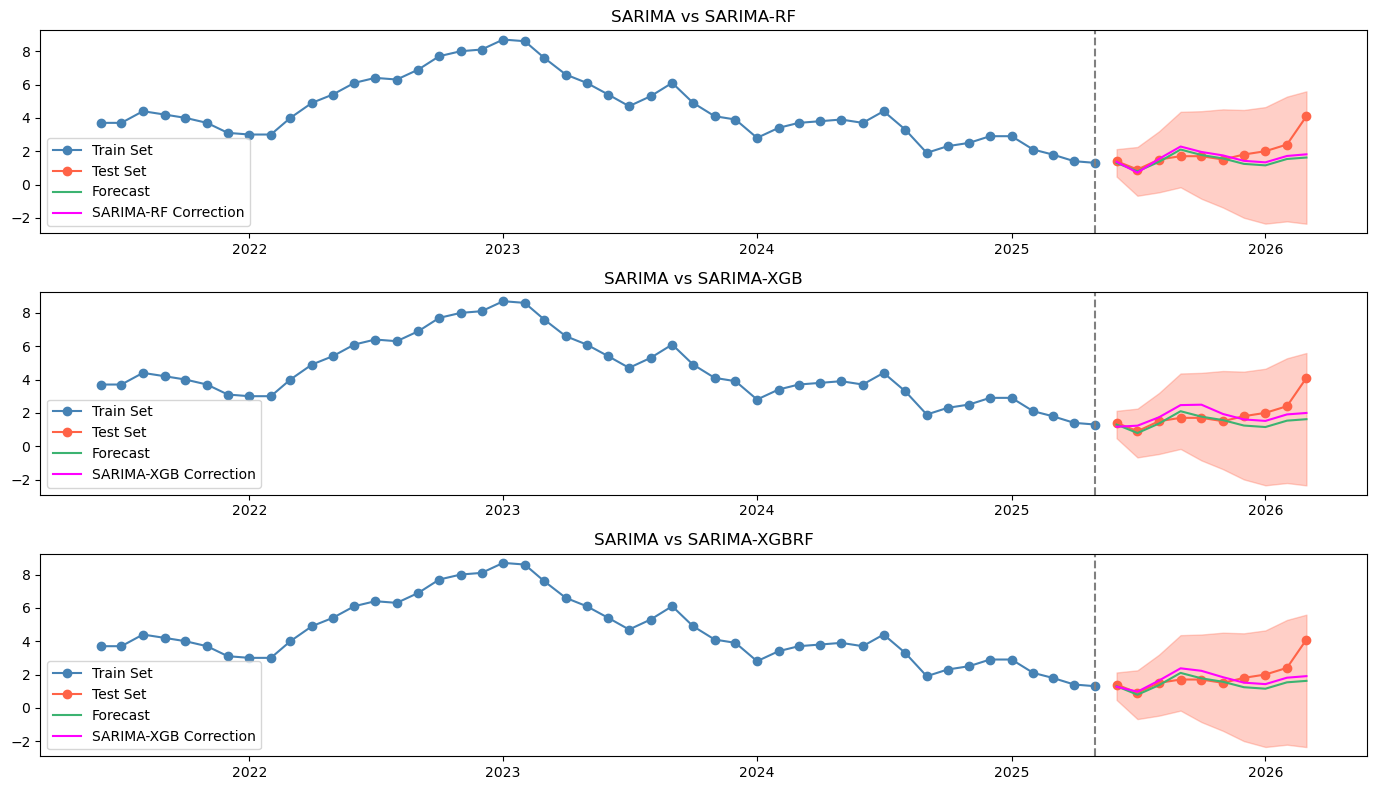

In [31]:
fig, (ax1,ax2,ax3) = plt.subplots(3, 1, figsize=(14,8))

ax1.plot(train['inflation'], color = 'steelblue', label='Train Set', marker='o')
ax1.plot(test['inflation'], color = 'tomato', label='Test Set',marker='o')
ax1.plot(forecast_df['forecast'], color='mediumseagreen', label='Forecast')
ax1.plot(test.dropna().index, sarima_rf_correction, color = 'magenta', label='SARIMA-RF Correction')
ax1.fill_between(forecast_df.index,
                forecast_df['lower_ci'],
                forecast_df['upper_ci'],
                color='tomato',
                alpha=0.3)
ax1.axvline(train.index.max(), color='grey', linestyle='--')
ax1.legend()
ax1.set_title('SARIMA vs SARIMA-RF')

ax2.plot(train['inflation'], color = 'steelblue', label='Train Set', marker='o')
ax2.plot(test['inflation'], color = 'tomato', label='Test Set',marker='o')
ax2.plot(forecast_df['forecast'], color='mediumseagreen', label='Forecast')
ax2.plot(test.dropna().index, corrected_xgb_forecast, color = 'magenta', label='SARIMA-XGB Correction')
ax2.fill_between(forecast_df.index,
            forecast_df['lower_ci'],
            forecast_df['upper_ci'],
            color='tomato',
            alpha=0.3)
ax2.axvline(train.index.max(), color='grey', linestyle='--')
ax2.legend()
ax2.set_title('SARIMA vs SARIMA-XGB')


ax3.plot(train['inflation'], color = 'steelblue', label='Train Set', marker='o')
ax3.plot(test['inflation'], color = 'tomato', label='Test Set',marker='o')
ax3.plot(forecast_df['forecast'], color='mediumseagreen', label='Forecast')
ax3.plot(test.dropna().index, ensemble_sarima, color = 'magenta', label='SARIMA-XGB Correction')
ax3.fill_between(forecast_df.index,
            forecast_df['lower_ci'],
            forecast_df['upper_ci'],
            color='tomato',
            alpha=0.3)
ax3.axvline(train.index.max(), color='grey', linestyle='--')
ax3.legend()
ax3.set_title('SARIMA vs SARIMA-XGBRF')

plt.tight_layout()
plt.savefig('prelimenary_plot1.png', dpi = 150, bbox_inches = 'tight')
plt.show()

In [21]:
print(f'SARIMA Baseline Benchmark:')
err_metrics(test['inflation'].dropna(), forecast.values)
print('')
print(f'SARIMA-RF Benchmark:')
err_metrics(test['inflation'].dropna(), sarima_rf_correction)
print('')
print(f'SARIMA-XGB Benchmark:')
err_metrics(test['inflation'].dropna(),corrected_xgb_forecast)
print('')
print(f'SARIMA-XGBRF Benchmark:')
err_metrics(test['inflation'].dropna(),ensemble_sarima)

SARIMA Baseline Benchmark:
MSE: 0.8155289828913558
RMSE: 0.903066433265768
MAE: 0.5647337379062976

SARIMA-RF Benchmark:
MSE: 0.6796783017924615
RMSE: 0.8244260438586724
MAE: 0.5367959366646491

SARIMA-XGB Benchmark:
MSE: 0.6566770903987337
RMSE: 0.8103561503430042
MAE: 0.606305249890314

SARIMA-XGBRF Benchmark:
MSE: 0.6471385412718972
RMSE: 0.804449216092537
MAE: 0.5527403376205546


{None}

### 5. Final Modeling and Conclusion 

#### 5.1 Full Dataset Modeling

In [22]:
# Refitting the Fulldataset to SARIMA with the same orders as before
inflation = df['inflation'].dropna()
inflation.index.freq = 'MS'
final_sarima = SARIMAX(
    inflation,
    order = arima_model.order,
    seasonal_order=arima_model.seasonal_order)

final_sarima_fit = final_sarima.fit(disp=False)

In [23]:
# Forecasting two observations ahead
final_forecast_obj = final_sarima_fit.get_forecast(steps=2)
final_forecast = final_forecast_obj.predicted_mean
final_conf_int = final_forecast_obj.conf_int()

In [24]:
# Getting the residual of final SARIMA model and setting variables for exogenous features
final_resid = final_sarima_fit.resid

final_X_train = df[df['inflation'].notna()][['sentiment','oil_brent']]
final_y_train = final_resid
final_X_train = final_X_train.iloc[1:]
final_y_train = final_y_train.iloc[1:]

In [25]:
# Refitting to RF model 
final_rf = rf_model.fit(final_X_train, final_y_train)
# RF forecast
final_rf_forecast = final_rf.predict(X_future)

In [26]:
final_xgb = xgb_model.fit(final_X_train, final_y_train)
final_xgb_forecast = final_xgb.predict(X_future)

In [27]:
final_ensemble_correction = final_forecast+ (final_rf_forecast+final_xgb_forecast)/2

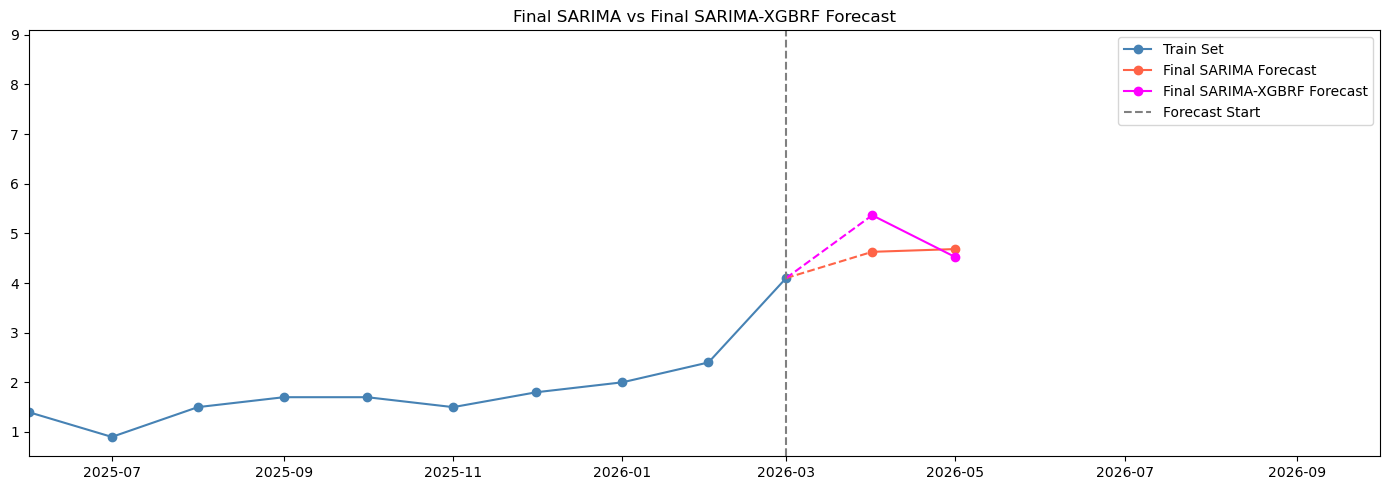

In [33]:
last_date = df['inflation'].dropna().index[-1]
final_forecast_index = pd.date_range(start=last_date, periods=3,freq='MS')[1:]


fig, ax = plt.subplots(figsize=(14,5))
ax.set_xlim(pd.Timestamp('2025-06-01'), pd.Timestamp('2026-10-01'))
ax.plot(df['inflation'].dropna(), color = 'steelblue', label='Train Set', marker='o')
ax.plot(final_forecast_index,final_forecast.values, color='tomato', label='Final SARIMA Forecast', marker='o')
ax.plot(final_forecast_index,final_ensemble_correction, color='magenta', label='Final SARIMA-XGBRF Forecast', marker='o')
# Get last observed point
last_obs_date = inflation.index[-1]
last_obs_value = inflation.iloc[-1]

# Connect observation to forecast
ax.plot([last_obs_date, final_forecast_index[0]], 
        [last_obs_value, final_forecast.values[0]], 
        color='tomato', linestyle='--')

ax.plot([last_obs_date, final_forecast_index[0]], 
        [last_obs_value, final_ensemble_correction.values[0]], 
        color='magenta', linestyle='--')
ax.axvline(last_date, color='grey', linestyle='--', label='Forecast Start')
ax.set_title('Final SARIMA vs Final SARIMA-XGBRF Forecast')
plt.legend()
plt.savefig('Final Forecast_plot.png', dpi = 150, bbox_inches = 'tight')
plt.tight_layout()
plt.show()

In [29]:
# Forecast Values

print("Final Forecast:")
print(f"April 2026 - SARIMA: {final_forecast.values[0]:.2f}, Ensemble: {final_ensemble_correction.values[0]:.2f}")
print(f"May 2026 - SARIMA: {final_forecast.values[1]:.2f}, Ensemble: {final_ensemble_correction.values[1]:.2f}")

Final Forecast:
April 2026 - SARIMA: 4.63, Ensemble: 5.37
May 2026 - SARIMA: 4.68, Ensemble: 4.52


### Conclusion and Findings

 - This project investigated whether macroeconomic indicators — specifically Brent crude oil prices and financial news sentiment — could meaningfully improve short-term Philippine inflation forecasting beyond a univariate SARIMA baseline.

 - Correlation analysis confirmed that both features carry a positive leading relationship with inflation: oil prices at lag 2 (r = 0.67) and finBERT sentiment scores at lag 2 (r = 0.44). USD-PHP exchange rate was initially hypothesized as a third feature, but correlation analysis using verifiable BSP and yfinance data produced weak results (r < 0.25 across all lags), suggesting that BSP monetary intervention may be suppressing the direct pass-through effect between exchange rate movements and inflation. The feature was dropped to maintain data integrity.

 - The hybrid SARIMA-XGBRF ensemble model outperformed the standalone SARIMA baseline with an RMSE of 0.804 compared to 0.903, representing a 20.73% improvement in forecasting accuracy. All three correction models — Random Forest, XGBoost, and their ensemble — consistently beat the baseline, confirming that exogenous macroeconomic features add meaningful predictive signal beyond what ARIMA can capture alone.

 - The final 2-month ahead forecast using real observed exogenous values projects April 2026 inflation at 5.37% and May 2026 at 4.52%, suggesting a short-term spike followed by partial moderation. Both figures remain elevated relative to the low inflation environment observed in mid-2025.

 - Limitations: The model is constrained by monthly data aggregation — oil prices and sentiment exhibit high daily volatility that is lost when averaged to monthly frequency. The correction layer is further limited by the near-white-noise behavior of SARIMA residuals, leaving minimal learnable signal for the ensemble models.
 - Finally, the 2-month forecast horizon is bounded by the availability of leading exogenous data; forecasting beyond this window would require separate models for the exogenous variables themselves.